# Compress_kt() vs  Compresspp_kt()

In [1]:
import numpy as np
import pandas as pd
from goodpoints import compress
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn import metrics
import time


seed = 42
n = 10_000
d = 20 # number of features (informative + redundant)
sigma = np.sqrt(2 * d)
gamma = 1 / (sigma**2) # for MMD calculation

# synthetic data
X, y = make_classification(
    n_samples = n, 
    n_features = d,   
    n_informative = int(d * 0.5),
    n_classes = 5,
    random_state = 42
)

## vs num_bins

for compresspp_kt() : 
Returns coreset of size sqrt(n') as row indices into X. 
    Here n' = the largest power of 4 less than or equal to n. 
- g: Oversampling parameter, a nonnegative integer
- num_bins: Number of bins, a power of 4 <= n
  
for compress_kt() : Returns coreset of size min(n', 2^g sqrt(n' * num_bins)) as row indices 
    into X. Here n' = num_bins times the largest power of 4 less than or equal 
    to n / num_bins. 
- g: Oversampling parameter, a nonnegative integer
- num_bins: Number of bins, a positive integer <= n

In [2]:
def generate_num_bins_pp_kt(n):
    bins = []
    k = 1
    while 4**k <= n:
        bins.append(4**k)
        k += 1
    return bins

def generate_num_bins_kt(n):
    bins = []
    for i in range(1, n//4):
        if n//i>4**2:
            bins.append(i)
    return bins

In [3]:
results_ppkt = []
results_kt = []

num_bins_pp_kt = generate_num_bins_pp_kt(n)
num_bins_kt = generate_num_bins_kt(n)

for num_bins in num_bins_pp_kt:
    id_cte_ppkt_gaussian = compress.compresspp_kt(X, kernel_type=b"gaussian", k_params=np.array([sigma**2]), g=0, num_bins=num_bins)

    results_ppkt.append({
        "n": n,
        "num_bins": num_bins,
        "num_points_selected": len(id_cte_ppkt_gaussian), 
        "kernel": "gaussian",
    })


for num_bins in num_bins_kt:
    id_cte_kt_gaussian = compress.compress_kt(X, kernel_type=b"gaussian", k_params=np.array([sigma**2]), g=0, num_bins=num_bins)

    results_kt.append({
        "n": n,
        "num_bins": num_bins,
        "num_points_selected": len(id_cte_kt_gaussian), 
        "kernel": "gaussian",
    })

print("Successfully calculated.")

results_ppkt = pd.DataFrame(results_ppkt)
results_kt = pd.DataFrame(results_kt)

Successfully calculated.


/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_81217/3585572040.py:32: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(0, results_kt["num_bins"].max() + 100)


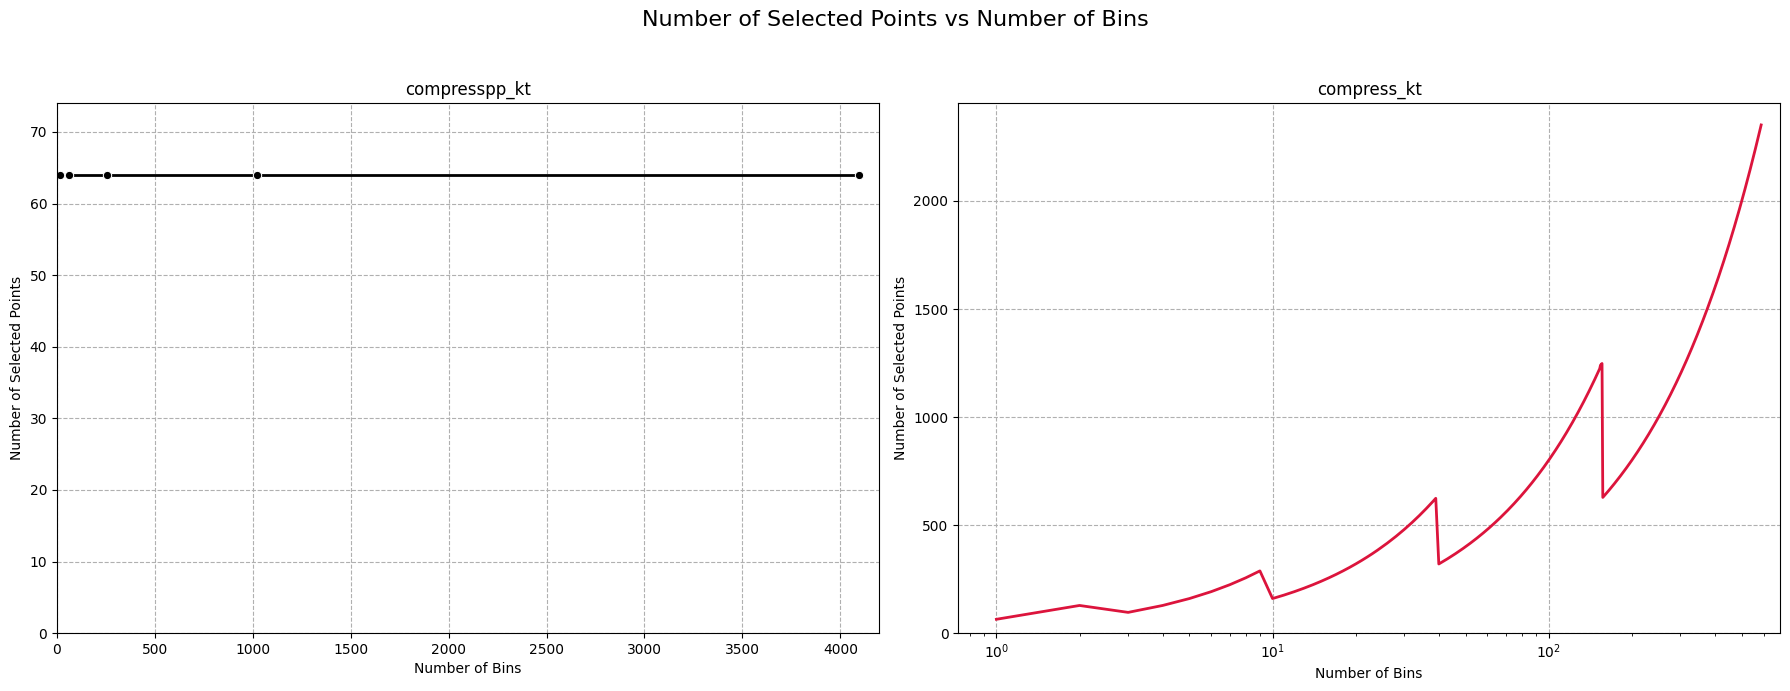

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.lineplot(
    data=results_ppkt,
    x="num_bins",
    y="num_points_selected",
    marker="o",
    linewidth=2,
    color="black",
    ax=ax1
)
ax1.set_title("compresspp_kt")
ax1.set_xlabel("Number of Bins")
ax1.set_ylabel("Number of Selected Points")
ax1.grid(True, linestyle="--")
ax1.set_xlim(0, results_ppkt["num_bins"].max() + 100)   
ax1.set_ylim(0, results_ppkt["num_points_selected"].max() + 10)

sns.lineplot(
    data=results_kt,
    x="num_bins",
    y="num_points_selected",
    linewidth=2,
    color="crimson",
    ax=ax2
)
ax2.set_title("compress_kt")
ax2.set_xlabel("Number of Bins")
ax2.set_ylabel("Number of Selected Points")
ax2.set_xscale("log")
ax2.grid(True, linestyle="--")
ax2.set_xlim(0, results_kt["num_bins"].max() + 100)        
ax2.set_ylim(0, results_kt["num_points_selected"].max() + 100)

plt.suptitle("Number of Selected Points vs Number of Bins", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [5]:
def get_theoretical_number_of_samples_in_kt(n, num_bins, g):
    max_power_of_4 = 1
    while max_power_of_4 * 4 <= n / num_bins:
        max_power_of_4 *= 4

    n_prime = num_bins * max_power_of_4

    coreset_size = min(n_prime, int(2 ** g * math.sqrt(n_prime * num_bins)))
    return coreset_size

I will check, whether the description of compress_kt() alligns with implementation:

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_81217/2445716608.py:27: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(0, results_kt["num_bins"].max() + 100)


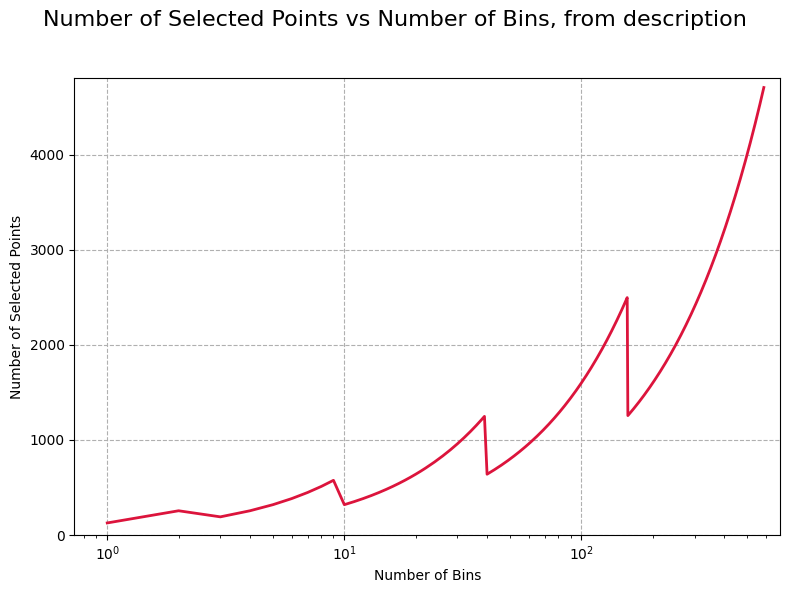

In [6]:
num_bins_kt = generate_num_bins_kt(n)
theoretical_number_of_samples = []

for num_bins in num_bins_kt:
    theoretical_number_of_samples.append(get_theoretical_number_of_samples_in_kt(n, num_bins, 1))

results_kt = pd.DataFrame({
    "num_bins": num_bins_kt,
    "num_points_selected": theoretical_number_of_samples
})

fig, ax2 = plt.subplots(figsize=(8, 6))

sns.lineplot(
    data=results_kt,
    x="num_bins",
    y="num_points_selected",
    linewidth=2,
    color="crimson",
    ax=ax2
)

ax2.set_xlabel("Number of Bins")
ax2.set_ylabel("Number of Selected Points")
ax2.set_xscale("log")
ax2.grid(True, linestyle="--")
ax2.set_xlim(0, results_kt["num_bins"].max() + 100)        
ax2.set_ylim(0, results_kt["num_points_selected"].max() + 100)

plt.suptitle("Number of Selected Points vs Number of Bins, from description", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



looks the same

## vs g

In [7]:
results_ppkt = []
results_kt = []

gs = np.arange(0, 31)

for g in gs:
    id_cte_ppkt_gaussian = compress.compresspp_kt(X, kernel_type=b"gaussian", k_params=np.array([sigma**2]), g=g)
    id_cte_kt_gaussian = compress.compress_kt(X, kernel_type=b"gaussian", k_params=np.array([sigma**2]), g=g)

    results_ppkt.append({
        "n": n,
        "g": g,
        "num_points_selected": len(id_cte_ppkt_gaussian), 
        "kernel": "gaussian",
    })

    results_kt.append({
        "n": n,
        "g": g,
        "num_points_selected": len(id_cte_kt_gaussian), 
        "kernel": "gaussian",
    })

print("Successfully calculated.")

results_ppkt = pd.DataFrame(results_ppkt)
results_kt = pd.DataFrame(results_kt)

Successfully calculated.


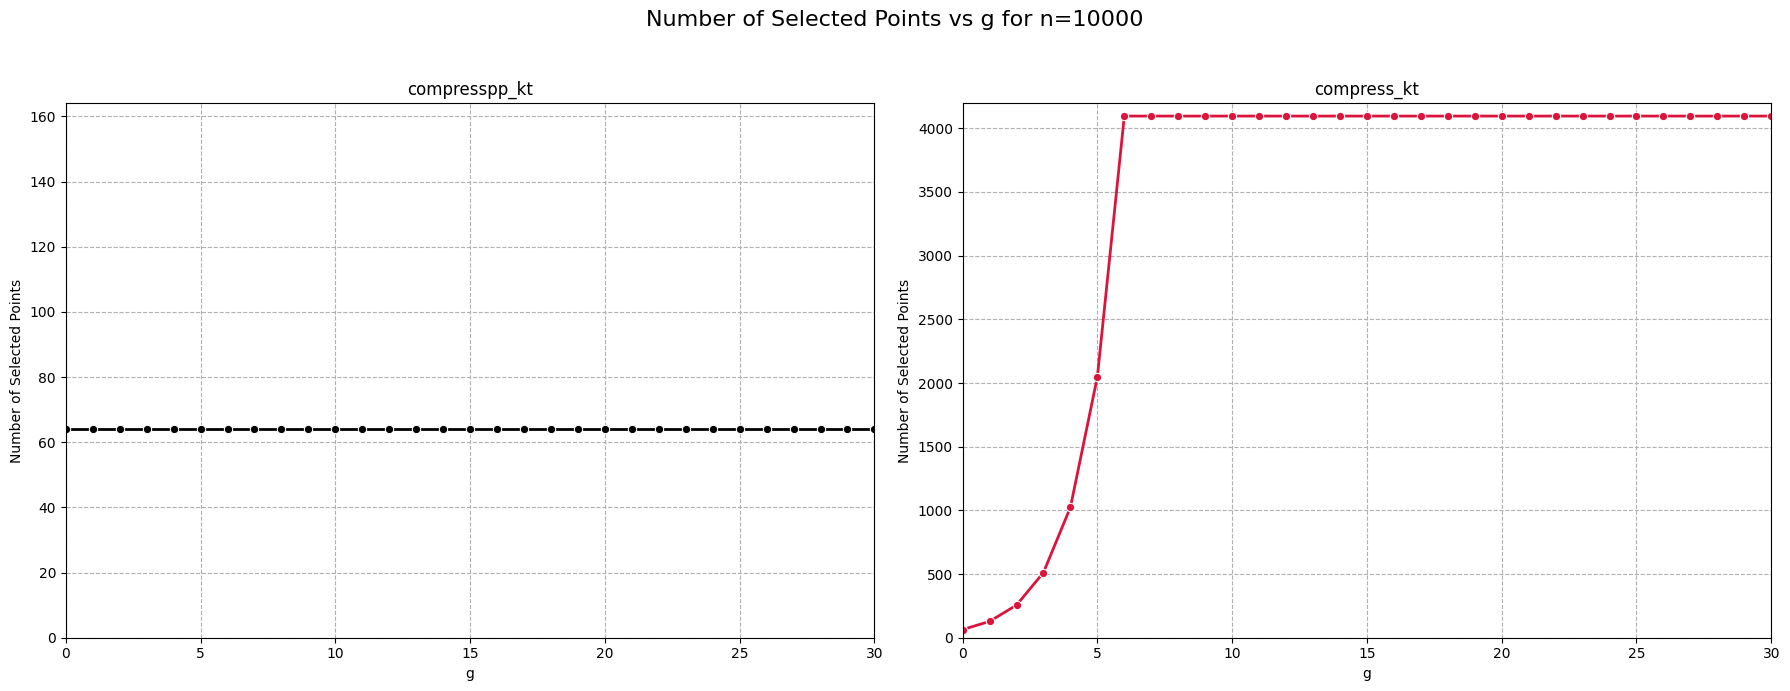

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.lineplot(
    data=results_ppkt,
    x="g",
    y="num_points_selected",
    marker="o",
    linewidth=2,
    color="black",
    ax=ax1
)
ax1.set_title("compresspp_kt")
ax1.set_xlabel("g")
ax1.set_ylabel("Number of Selected Points")
ax1.grid(True, linestyle="--")
ax1.set_xlim(gs.min(), gs.max())
ax1.set_ylim(0, results_ppkt["num_points_selected"].max() + 100)

sns.lineplot(
    data=results_kt,
    x="g",
    y="num_points_selected",
    marker="o",
    linewidth=2,
    color="crimson",
    ax=ax2
)

ax2.set_title("compress_kt")
ax2.set_xlabel("g")
ax2.set_ylabel("Number of Selected Points")
ax2.grid(True, linestyle="--")
ax2.set_xlim(gs.min(), gs.max())
ax2.set_ylim(0, results_kt["num_points_selected"].max() + 100)

plt.suptitle(f"Number of Selected Points vs g for n={n}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


There are too large jumps between the data points on the right plot.

# MMD

In [9]:
def d_mmd(X, Y, gamma):
    """ 
    source: https://github.com/jindongwang/transferlearning/blob/master/code/distance/mmd_numpy_sklearn.py
    MMD using rbf (gaussian) kernel (i.e., k(x,y) = exp(-gamma * ||x-y||^2))
    """
    XX = metrics.pairwise.rbf_kernel(X, X, gamma)
    YY = metrics.pairwise.rbf_kernel(Y, Y, gamma)
    XY = metrics.pairwise.rbf_kernel(X, Y, gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

## vs g

In [10]:
results = []

gs = np.arange(0, 11)
n_repeats = 33  

for g in gs:
    for repeat in range(n_repeats):
        t_start = time.time()
        id_cte_kt_gaussian = compress.compress_kt(X, kernel_type=b"gaussian", k_params=np.array([sigma**2]), g=g)
        t = time.time() - t_start
        mmd = d_mmd(X, X[id_cte_kt_gaussian], gamma)

        results.append({
            "method": "compress_kt",
            "repeat": repeat,
            "g": g,
            "n": n,
            "mmd": mmd,
            "t": t,
            "num_points_selected": len(id_cte_kt_gaussian),
        })

        t_start = time.time()
        id_cte_ppkt_gaussian = compress.compresspp_kt(X, kernel_type=b"gaussian", k_params=np.array([sigma**2]), g=g)
        t = time.time() - t_start
        mmd = d_mmd(X, X[id_cte_ppkt_gaussian], gamma)

        results.append({
            "method": "compresspp_kt",
            "repeat": repeat,
            "g": g,
            "n": n,
            "mmd": mmd,
            "t": t,
            "num_points_selected": len(id_cte_ppkt_gaussian),
        })

print("Successfully calculated.")
results = pd.DataFrame(results)

Successfully calculated.


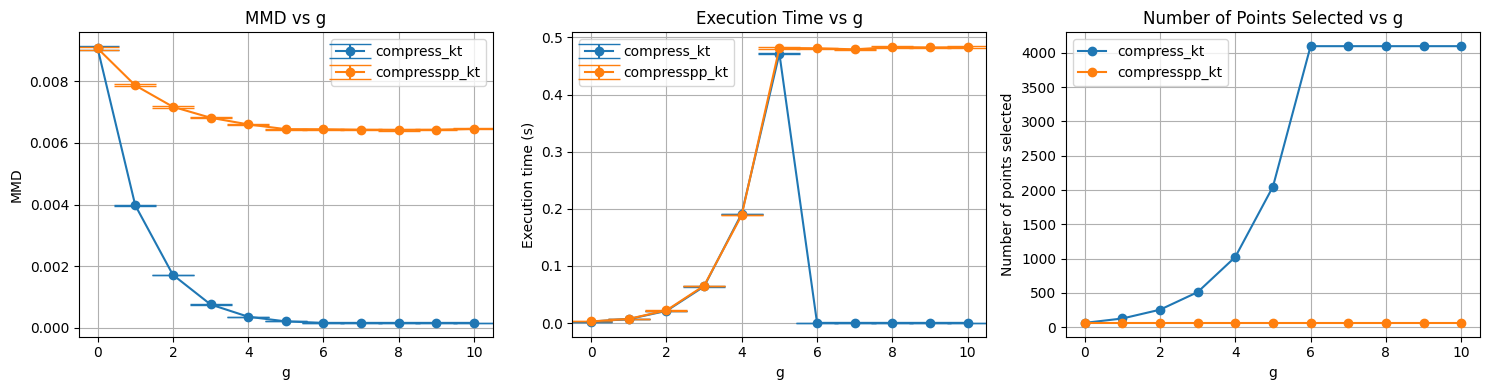

In [11]:
agg_results = results.groupby(['method', 'g']).agg(
    mmd_mean=('mmd', 'mean'),
    mmd_se=('mmd', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    t_mean=('t', 'mean'),
    t_se=('t', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    num_points_selected=('num_points_selected', 'max')
).reset_index()

plt.figure(figsize=(15, 4))

# --- MMD vs g ---
plt.subplot(1, 3, 1)
for method in ['compress_kt', 'compresspp_kt']:
    subset = agg_results[agg_results['method'] == method]
    plt.errorbar(
        subset['g'], subset['mmd_mean'], yerr=subset['mmd_se'],
        marker='o', label=method, capsize=15
    )
plt.xlabel('g')
plt.ylabel('MMD')
plt.title('MMD vs g')
plt.legend()
plt.grid(True)

# --- Execution time vs g ---
plt.subplot(1, 3, 2)
for method in ['compress_kt', 'compresspp_kt']:
    subset = agg_results[agg_results['method'] == method]
    plt.errorbar(
        subset['g'], subset['t_mean'], yerr=subset['t_se'],
        marker='o', label=method, capsize=15
    )
plt.xlabel('g')
plt.ylabel('Execution time (s)')
plt.title('Execution Time vs g')
plt.legend()
plt.grid(True)

# --- Number of points selected vs g ---
plt.subplot(1, 3, 3)
for method in ['compress_kt', 'compresspp_kt']:
    subset = agg_results[agg_results['method'] == method]
    plt.errorbar(
        subset['g'], subset['num_points_selected'],
        marker='o', label=method
    )
plt.xlabel('g')
plt.ylabel('Number of points selected')
plt.title('Number of Points Selected vs g')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


compress_kt becomes better according to MMD and faster, just because it samples more points than compresspp_kt.

## vs num_bins

In [12]:
num_bins_pp_kt = generate_num_bins_pp_kt(n)
num_bins_kt = generate_num_bins_kt(n)

log_indices = np.logspace(0, np.log10(len(num_bins_kt) - 1), num=15, dtype=int)
log_indices = np.unique(log_indices)
num_bins_kt = [num_bins_kt[i] for i in log_indices]
results = []

n_repeats = 33

for num_bins in num_bins_pp_kt:
    for repeat in range(n_repeats):
        t_start = time.time()
        id_cte_ppkt_gaussian = compress.compresspp_kt(X, kernel_type=b"gaussian", k_params=np.array([sigma**2]), num_bins=num_bins)
        t = time.time() - t_start
        mmd = d_mmd(X, X[id_cte_ppkt_gaussian], gamma)
        
        results.append({
            "method": "compresspp_kt",
            "repeat": repeat,
            "num_bins": num_bins,
            "n": n,
            "mmd": mmd,
            "t": t,
            "num_points_selected": len(id_cte_ppkt_gaussian),
        })


for num_bins in num_bins_kt:
    for repeat in range(n_repeats):
        t_start = time.time()
        id_cte_kt_gaussian = compress.compress_kt(X, kernel_type=b"gaussian", k_params=np.array([sigma**2]), num_bins=num_bins, g=0)
        t = time.time() - t_start
        mmd = d_mmd(X, X[id_cte_kt_gaussian], gamma)

        results.append({
            "method": "compress_kt",
            "repeat": repeat,
            "num_bins": num_bins,
            "n": n,
            "mmd": mmd,
            "t": t,
            "num_points_selected": len(id_cte_kt_gaussian),
        })

print("Successfully calculated.")
results = pd.DataFrame(results)


Successfully calculated.


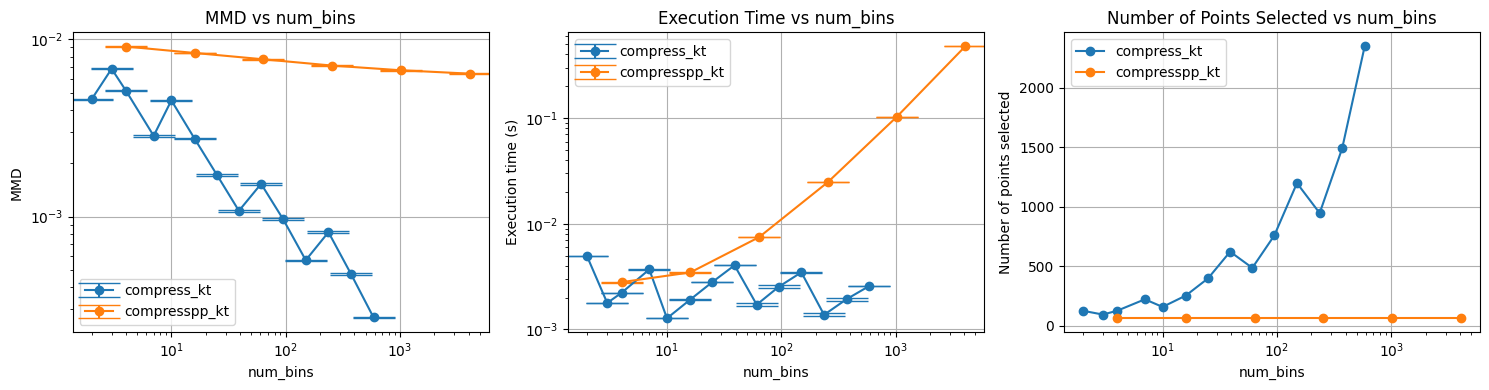

In [13]:
agg_results = results.groupby(['method', 'num_bins']).agg(
    mmd_mean=('mmd', 'mean'),
    mmd_se=('mmd', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    t_mean=('t', 'mean'),
    t_se=('t', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    num_points_selected=('num_points_selected', 'max')
).reset_index()

plt.figure(figsize=(15, 4))

# --- MMD vs num_bins ---
plt.subplot(1, 3, 1)
for method in ['compress_kt', 'compresspp_kt']:
    subset = agg_results[agg_results['method'] == method]
    plt.errorbar(
        subset['num_bins'], subset['mmd_mean'], yerr=subset['mmd_se'],
        marker='o', label=method, capsize=15,
    )
plt.xlabel('num_bins')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('MMD')
plt.title('MMD vs num_bins')
plt.legend()
plt.grid(True)

# --- Execution time vs num_bins ---
plt.subplot(1, 3, 2)
for method in ['compress_kt', 'compresspp_kt']:
    subset = agg_results[agg_results['method'] == method]
    plt.errorbar(
        subset['num_bins'], subset['t_mean'], yerr=subset['t_se'],
        marker='o', label=method, capsize=15, 
    )
plt.xlabel('num_bins')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Execution time (s)')
plt.title('Execution Time vs num_bins')
plt.legend()
plt.grid(True)

# --- Number of points selected vs num_bins ---
plt.subplot(1, 3, 3)
for method in ['compress_kt', 'compresspp_kt']:
    subset = agg_results[agg_results['method'] == method]
    plt.errorbar(
        subset['num_bins'], subset['num_points_selected'],
        marker='o', label=method
    )
plt.xlabel('num_bins')
plt.xscale('log')
plt.ylabel('Number of points selected')
plt.title('Number of Points Selected vs num_bins')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
